<a href="https://colab.research.google.com/github/ClassNeuralNetwork/Classification-Heart-Attack-Risk-Prediction/blob/main/Heart_Attack_Risk_Prediction_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto 1º unidade da disciplina de Redes Neurais - Heart Attack Risk Prediction Dataset


26/03: inicio do projeto


02/04: finalização


08/04: Apresentação


08/04: envio do artigo no sigaa




# Importando Bibliotecas

impontando bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import kagglehub
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import class_weight

In [ ]:
#carregando o dataset
path = kagglehub.dataset_download("iamsouravbanerjee/heart-attack-prediction-dataset")
df = pd.read_csv(f'{path}/heart_attack_prediction_dataset.csv')


Using Colab cache for faster access to the 'heart-attack-prediction-dataset' dataset.


In [ ]:
# renomeando colunas
df.rename(columns={
    'Patient ID': 'Patient_ID', 'Blood Pressure': 'Blood_Pressure',
    'Heart Rate': 'Heart_Rate', 'Exercise Hours Per Week': 'Exercise_Hours_Per_Week',
    'Sedentary Hours Per Day': 'Sedentary_Hours_Per_Day',
    'Physical Activity Days Per Week': 'Physical_Activity_Days_Per_Week',
    'Sleep Hours Per Day': 'Sleep_Hours_Per_Day', 'Family History': 'Family_History',
    'Alcohol Consumption': 'Alcohol_Consumption', 'Medication Use': 'Medication_Use',
    'Previous Heart Problems': 'Previous_Heart_Problems', 'Stress Level': 'Stress_Level',
    'Heart Attack Risk': 'Heart_Attack_Risk'
}, inplace=True)


In [ ]:
# tratando os dados de pressao sanguinea e dividindo bp_systolic e bp_diastolic
df[['BP_Systolic', 'BP_Diastolic']] = df['Blood_Pressure'].str.split('/', expand=True).astype(float)

In [ ]:
# removendo colunas q podem gerar ruido
drop_cols = ['Patient_ID', 'Blood_Pressure', 'Country', 'Continent', 'Hemisphere']
df_model = df.drop(columns=drop_cols, errors='ignore')

# Pré Processamento

In [ ]:
# variaveis categoricas sex e diet
le = LabelEncoder()
for col in ['Sex', 'Diet']:
    df_model[col] = le.fit_transform(df_model[col])

In [ ]:
#separando as variaveis de entrada e saida
X = df_model.drop(['Heart_Attack_Risk'], axis=1)
y = df_model['Heart_Attack_Risk']

In [ ]:
# divisao de treino/teste
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Padronização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Adicionando o import necessário para 'class_weight'
from sklearn.utils import class_weight

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)



In [ ]:
#contrução do modelo
def build_optimized_model(input_shape):
    model = models.Sequential([
        # Camada de Entrada + Oculta 1 (Reduzida para evitar overfitting)
        layers.Dense(128, activation='relu', input_shape=(input_shape,)),
        layers.Dropout(0.1),

        # Camada Oculta 2
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),

        # Camada Oculta 3
        layers.Dense(8, activation='relu'),
        #layers.Dropout(0.1),

        # Saída
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Recall()]
    )
    return model

model = build_optimized_model(X_train.shape[1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
df_model['Heart_Attack_Risk'].value_counts()

,count
Heart_Attack_Risk,
0,5624
1,3139


In [ ]:
#treinamento ultilizando earlystopping para impedir o overfitting

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
class_weights = dict(zip(np.unique(y_train), weights))
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5408 - loss: 0.7056 - recall_21: 0.4297 - val_accuracy: 0.5128 - val_loss: 0.6982 - val_recall_21: 0.4076
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5182 - loss: 0.7020 - recall_21: 0.4555 - val_accuracy: 0.5086 - val_loss: 0.6959 - val_recall_21: 0.4116
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5284 - loss: 0.6981 - recall_21: 0.4635 - val_accuracy: 0.4971 - val_loss: 0.6977 - val_recall_21: 0.4659
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5244 - loss: 0.6962 - recall_21: 0.4779 - val_accuracy: 0.4936 - val_loss: 0.6964 - val_recall_21: 0.4438
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5321 - loss: 0.6928 - recall_21: 0.4993 - val_accuracy: 0.4872 - val_loss: 0.6974 - val_recall_21: 0.4498
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5184 - loss: 0.6940 - recall_21: 0.5052 - val_accuracy: 0.4850 - val

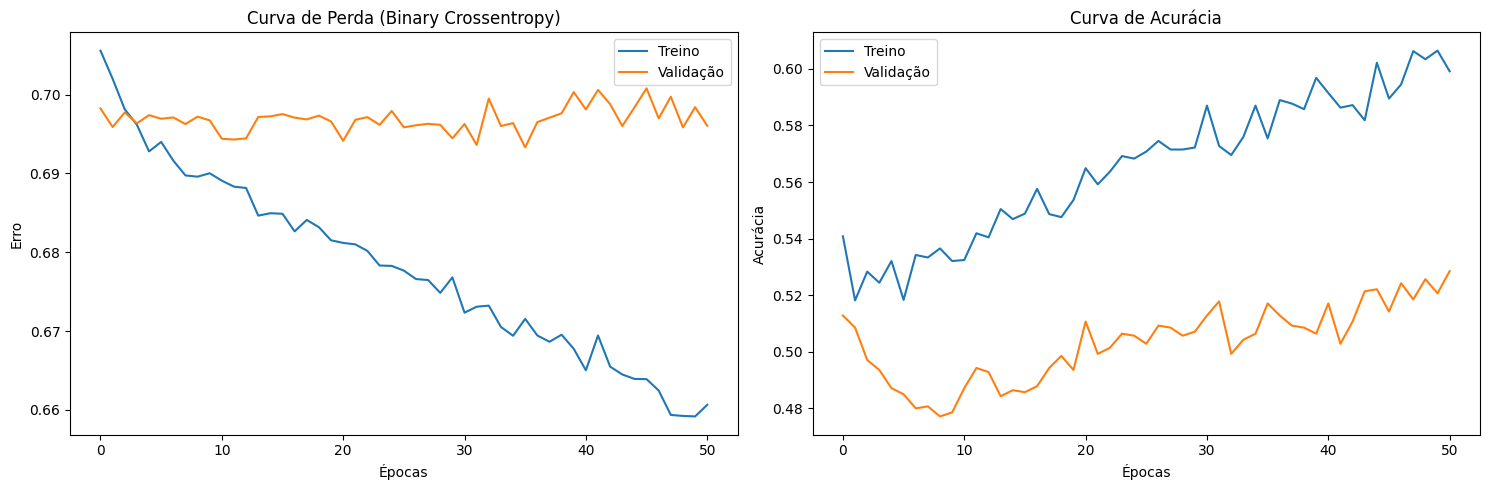


--- Resultados Finais no Teste ---
Acurácia: 50.31%
Recall (Sensibilidade): 45.54%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de Perda
ax1.plot(history.history['loss'], label='Treino')
ax1.plot(history.history['val_loss'], label='Validação')
ax1.set_title('Curva de Perda (Binary Crossentropy)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Erro')
ax1.legend()

# Gráfico de Acurácia
ax2.plot(history.history['accuracy'], label='Treino')
ax2.plot(history.history['val_accuracy'], label='Validação')
ax2.set_title('Curva de Acurácia')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Acurácia')
ax2.legend()

plt.tight_layout()
plt.show()

results = model.evaluate(X_test, y_test, verbose=0)
print(f"\n--- Resultados Finais no Teste ---")
print(f"Acurácia: {results[1]*100:.2f}%")
print(f"Recall (Sensibilidade): {results[2]*100:.2f}%")

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


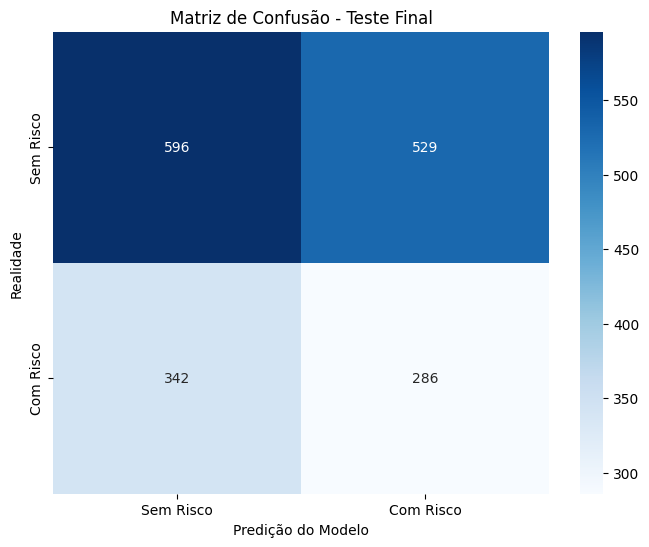


RELATÓRIO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

   Sem Risco       0.64      0.53      0.58      1125
   Com Risco       0.35      0.46      0.40       628

    accuracy                           0.50      1753
   macro avg       0.49      0.49      0.49      1753
weighted avg       0.53      0.50      0.51      1753



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Fazendo as predições no conjunto de teste
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sem Risco', 'Com Risco'],
            yticklabels=['Sem Risco', 'Com Risco'])
plt.title('Matriz de Confusão - Teste Final')
plt.ylabel('Realidade')
plt.xlabel('Predição do Modelo')
plt.show()

# Relatório de Métricas (Precision, Recall, F1-Score)
print("\n" + "="*30)
print("RELATÓRIO DE CLASSIFICAÇÃO")
print("="*30)
print(classification_report(y_test, y_pred, target_names=['Sem Risco', 'Com Risco']))
